# LSTM - Model

### Import all the necessary libraries and frameworks

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

### Load data

In [98]:
data_path = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
df = pd.read_excel(data_path)
df['date'] = pd.to_datetime(df['date'])

all_results = []

### Initial setup

In [99]:
TARGETS = ['RECESS', 'RECESS_OVER', 'RECESS_PERIOD']
target_name = "RECESS"
exclude_cols = ['date', 'Country'] + TARGETS
feature_cols = [col for col in df.columns if col not in exclude_cols]

In [100]:
df.dropna(subset=feature_cols + [target_name], inplace=True)
df['country_id'] = LabelEncoder().fit_transform(df['Country'])
feature_cols.append('country_id')
df.sort_values(['Country', 'date'], inplace=True)

### Early Stopping Configuration

In [101]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

### Data cutoffs for data split

In [102]:
train_start = "1995-01-01"
train_end = "2009-12-31"
val_start = "2010-01-01"
val_end = "2018-12-31"
test_start = "2019-01-01"
test_end = "2024-05-31"

### Split the data

In [103]:
df_train = df[(df['date'] >= train_start) & (df['date'] <= train_end)].copy()
df_val = df[(df['date'] >= val_start) & (df['date'] <= val_end)].copy()
df_test = df[(df['date'] >= test_start) & (df['date'] <= test_end)].copy()

### Sliding Window

In [104]:
time_steps = 24

### Train

In [105]:
X_train, y_train = [], []
for _, group in df_train.groupby('Country'):
    group = group.sort_values('date').reset_index(drop=True)
    for i in range(len(group) - time_steps):
        X_train.append(group.loc[i:i+time_steps-1, feature_cols].values)
        y_train.append(group.loc[i+time_steps, target_name])

X_train = np.array(X_train)
y_train = np.array(y_train)


### Validation

In [106]:
X_val, y_val = [], []
for _, group in df_val.groupby('Country'):
    group = group.sort_values('date').reset_index(drop=True)
    for i in range(len(group) - time_steps):
        X_val.append(group.loc[i:i+time_steps-1, feature_cols].values)
        y_val.append(group.loc[i+time_steps, target_name])

X_val = np.array(X_val)
y_val = np.array(y_val)

### Testing

In [107]:
X_test, y_test = [], []
for _, group in df_test.groupby('Country'):
    group = group.sort_values('date').reset_index(drop=True)
    for i in range(len(group) - time_steps):
        X_test.append(group.loc[i:i+time_steps-1, feature_cols].values)
        y_test.append(group.loc[i+time_steps, target_name])

X_test = np.array(X_test)
y_test = np.array(y_test)

In [108]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 686 samples
Validation: 504 samples
Test: 240 samples


### Model builder - LSTM Sequential

In [109]:
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Training the model

In [110]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6180 - loss: 0.6277 - val_accuracy: 0.5893 - val_loss: 0.6327
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7807 - loss: 0.4636 - val_accuracy: 0.6071 - val_loss: 0.6153
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8566 - loss: 0.3495 - val_accuracy: 0.6012 - val_loss: 0.8325
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8665 - loss: 0.2961 - val_accuracy: 0.6369 - val_loss: 0.8484
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8943 - loss: 0.2601 - val_accuracy: 0.6409 - val_loss: 0.8221
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9162 - loss: 0.2127 - val_accuracy: 0.6052 - val_loss: 1.0888
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9492 - loss: 0.1474 - val_accuracy: 0.6508 - val_loss: 0.9741
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9215 - loss: 0.1908 - val_accuracy: 0.6230 -

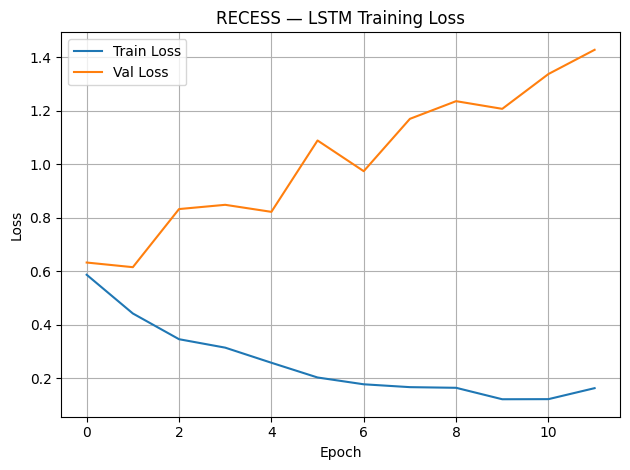

In [111]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{target_name} — LSTM Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Prediction

In [112]:
y_pred = model.predict(X_test).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


### Model performance

In [113]:
# Apply threshold to convert probabilities to binary predictions
threshold = 0.5
y_pred_binary = (y_pred >= threshold).astype(int)

In [114]:
auc = roc_auc_score(y_test, y_pred)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)
accuracy = accuracy_score(y_test, y_pred_binary)

In [115]:
print(f"[RESULTS] {target_name} — Sequential LSTM")
print(f"AUC:       {auc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Threshold: {threshold}")


[RESULTS] RECESS — Sequential LSTM
AUC:       0.7178
F1 Score:  0.2330
Precision: 0.1326
Recall:    0.9600
Accuracy:  0.3417
Threshold: 0.5


In [116]:
all_results.append({
    "Model": "Bidirectional LSTM",
    "Target": target_name,
    "AUC": auc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": threshold
})


### Building a Bidirectional LSTM

In [117]:
model_bi = Sequential()
model_bi.add(Bidirectional(LSTM(64, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
model_bi.add(Dropout(0.4))
model_bi.add(Dense(1, activation='sigmoid'))
model_bi.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Training the model

In [118]:
history_bi = model_bi.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6589 - loss: 0.6229 - val_accuracy: 0.6389 - val_loss: 0.6253
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8041 - loss: 0.4459 - val_accuracy: 0.5893 - val_loss: 0.7416
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8539 - loss: 0.3385 - val_accuracy: 0.6032 - val_loss: 0.9663
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8965 - loss: 0.2355 - val_accuracy: 0.5714 - val_loss: 1.1355
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9193 - loss: 0.2160 - val_accuracy: 0.6310 - val_loss: 1.0651
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9048 - loss: 0.2451 - val_accuracy: 0.6131 - val_loss: 1.0585
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9466 - loss: 0.1381 - val_accuracy: 0.6409 - val_loss: 1.2208
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9074 - loss: 0.2077 - val_accuracy: 0.66

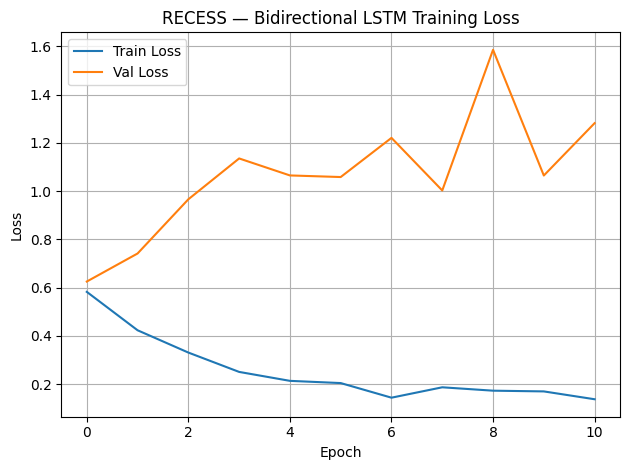

In [119]:
plt.plot(history_bi.history['loss'], label='Train Loss')
plt.plot(history_bi.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{target_name} — Bidirectional LSTM Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [120]:
y_pred_bi = model_bi.predict(X_test).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


### Model performance

In [121]:
# Apply threshold to convert probabilities to binary predictions
threshold = 0.5
y_pred_binary_bi = (y_pred_bi >= threshold).astype(int)

In [122]:
auc_bi = roc_auc_score(y_test, y_pred_bi)
precision_bi = precision_score(y_test, y_pred_binary_bi)
recall_bi = recall_score(y_test, y_pred_binary_bi)
f1_bi = f1_score(y_test, y_pred_binary_bi)
accuracy_bi = accuracy_score(y_test, y_pred_binary_bi)

In [123]:
print(f"[RESULTS] {target_name} — Bidirectional LSTM")
print(f"AUC:       {auc_bi:.4f}")
print(f"F1 Score:  {f1_bi:.4f}")
print(f"Precision: {precision_bi:.4f}")
print(f"Recall:    {recall_bi:.4f}")
print(f"Accuracy:  {accuracy_bi:.4f}")
print(f"Threshold: {threshold}")

[RESULTS] RECESS — Bidirectional LSTM
AUC:       0.6428
F1 Score:  0.2857
Precision: 0.1970
Recall:    0.5200
Accuracy:  0.7292
Threshold: 0.5


### Adding to the results dataframe

In [124]:
all_results.append({
    "Model": "Bidirectional LSTM",
    "Target": target_name,
    "AUC": auc_bi,
    "F1": f1_bi,
    "Precision": precision_bi,
    "Recall": recall_bi,
    "Accuracy": accuracy_bi,
    "Threshold": threshold
})

### Building a stacked LSTM

In [125]:
model_stacked = Sequential()
model_stacked.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_stacked.add(Dropout(0.3))
model_stacked.add(LSTM(32, return_sequences=False))
model_stacked.add(Dropout(0.3))
model_stacked.add(Dense(1, activation='sigmoid'))
model_stacked.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Training the model

In [126]:
history_stacked = model_stacked.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5845 - loss: 0.6449 - val_accuracy: 0.5198 - val_loss: 0.7204
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7859 - loss: 0.4887 - val_accuracy: 0.5040 - val_loss: 0.8419
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7986 - loss: 0.4109 - val_accuracy: 0.6111 - val_loss: 0.7991
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8529 - loss: 0.3207 - val_accuracy: 0.5516 - val_loss: 1.0465
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8553 - loss: 0.2863 - val_accuracy: 0.6032 - val_loss: 0.9107
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9213 - loss: 0.2230 - val_accuracy: 0.5893 - val_loss: 1.0295
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9020 - loss: 0.2222 - val_accuracy: 0.5774 - val_loss: 1.1163
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9418 - loss: 0.1727 - val_accuracy: 0.

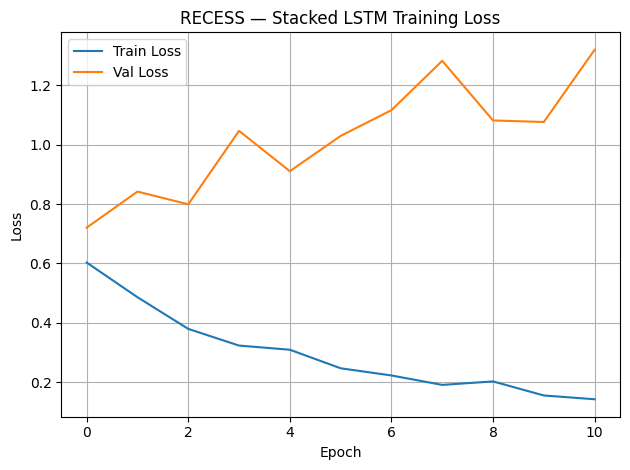

In [127]:
plt.plot(history_stacked.history['loss'], label='Train Loss')
plt.plot(history_stacked.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{target_name} — Stacked LSTM Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Prediction

In [128]:
y_pred_stacked = model_stacked.predict(X_test).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


### Performance

In [129]:
# Apply threshold to convert probabilities to binary predictions
threshold = 0.5
y_pred_binary_stacked = (y_pred_stacked >= threshold).astype(int)

In [130]:
auc_bi = roc_auc_score(y_test, y_pred_stacked)
precision_bi = precision_score(y_test, y_pred_binary_stacked)
recall_bi = recall_score(y_test, y_pred_binary_stacked)
f1_bi = f1_score(y_test, y_pred_binary_stacked)
accuracy_bi = accuracy_score(y_test, y_pred_binary_stacked)

In [131]:
print(f"[RESULTS] {target_name} — Stacked LSTM")
print(f"AUC:       {auc_bi:.4f}")
print(f"F1 Score:  {f1_bi:.4f}")
print(f"Precision: {precision_bi:.4f}")
print(f"Recall:    {recall_bi:.4f}")
print(f"Accuracy:  {accuracy_bi:.4f}")
print(f"Threshold: {threshold}")


[RESULTS] RECESS — Stacked LSTM
AUC:       0.6450
F1 Score:  0.0879
Precision: 0.0606
Recall:    0.1600
Accuracy:  0.6542
Threshold: 0.5


In [132]:
all_results.append({
    "Model": "Bidirectional LSTM",
    "Target": target_name,
    "AUC": auc_bi,
    "F1": f1_bi,
    "Precision": precision_bi,
    "Recall": recall_bi,
    "Accuracy": accuracy_bi,
    "Threshold": threshold
})

### Model comparison

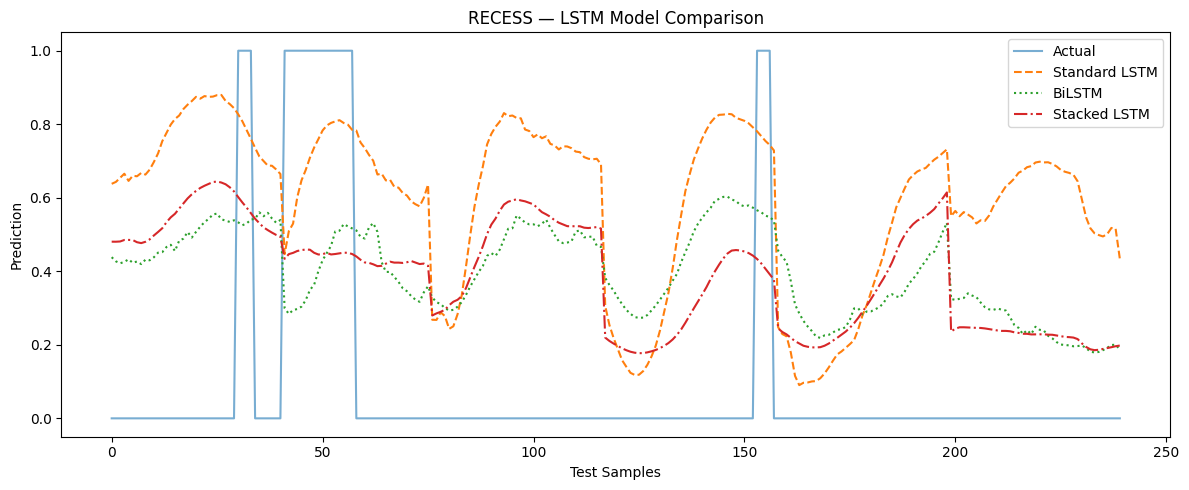

In [133]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual', alpha=0.6)
plt.plot(y_pred, label='Standard LSTM', linestyle='--')
plt.plot(y_pred_bi, label='BiLSTM', linestyle=':')
plt.plot(y_pred_stacked, label='Stacked LSTM', linestyle='-.')
plt.title(f"{target_name} — LSTM Model Comparison")
plt.xlabel("Test Samples")
plt.ylabel("Prediction")
plt.legend()
plt.tight_layout()
plt.show()

### Dataframe comparing the models

In [134]:
results_df = pd.DataFrame(all_results)
results_df

,Model,Target,AUC,F1,Precision,Recall,Accuracy,Threshold
0,Bidirectional LSTM,RECESS,0.717767,0.233010,0.132597,0.96,0.341667,0.5
1,Bidirectional LSTM,RECESS,0.642791,0.285714,0.196970,0.52,0.729167,0.5
2,Bidirectional LSTM,RECESS,0.645023,0.087912,0.060606,0.16,0.654167,0.5


### Saving the results

In [135]:
results_df.to_csv(f"../data/model_performance/LSTM_results_{target_name}.csv", index=False)